<a href="https://colab.research.google.com/github/alicegussoni/AlgorithmsForMassiveData_Project/blob/main/Finding_similar_items_GussoniAlice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Finding similar items*

---


The aim of the following project is to implement a detectors of pairs of similar abstract in scientific papers applying Jaccard similarity.
It was implemented using Python 3 as language.
MinHash and LSH were the two principal algorithm used

In [1]:
!pip install kaggle
!pip install pandas
!pip install numpy
!pip install datasketch

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = "alicegussoni"
os.environ['KAGGLE_KEY'] = "KGAT_f12f6c0d1d42aaa15a78272038cd73a8"
!kaggle datasets download -d Cornell-University/arxiv

Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
arxiv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import zipfile
with zipfile.ZipFile('arxiv.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Download completed")

Download completed


In [34]:
# subsample of the dataset
import json
import pandas as pd
import numpy as np
np.random.seed(42)

USE_SUBSAMPLE = True
SUBSAMPLE_SIZE = 20000

data = []

with open("dataset/arxiv-metadata-oai-snapshot.json") as f:
    for i, line in enumerate(f):
        if USE_SUBSAMPLE and i >= SUBSAMPLE_SIZE:
            break
        data.append(json.loads(line))

df = pd.DataFrame(data)
df.columns
df = df[['id', 'abstract']]
df.head()

,id,abstract
0,0704.0001,A fully differential calculation in perturba...
1,0704.0002,"We describe a new algorithm, the $(k,\ell)$-..."
2,0704.0003,The evolution of Earth-Moon system is descri...
3,0704.0004,We show that a determinant of Stirling cycle...
4,0704.0005,In this paper we show how to compute the $\L...


In [5]:
df.sample(5)

,id,abstract
6816,0705.2814,A three-dimensional nonlinear dynamo process...
11442,0706.2756,Various types of topological defects in grap...
4567,0705.0565,In order to describe Lambda(1405) as a reson...
15364,0707.2194,We review briefly the concepts underlying co...
10492,0706.1806,For a function g(w) analytic and univalent i...


Preprocessing of the dataset

---
The subset was analyzed to remove all the possible null values and thene the principal statistical measures were calculated




In [35]:
df["abstract"].isnull().sum()
df = df.dropna(subset= ["abstract"])

df["length_characters"] = df["abstract"].apply(len)
df["length_words"] = df["abstract"].apply(lambda x: len(x.split()))
df["length_words"].describe()

,length_words
count,20000.000000
mean,121.422950
std,62.868849
min,2.000000
25%,76.000000
50%,109.000000
75%,158.000000
max,342.000000


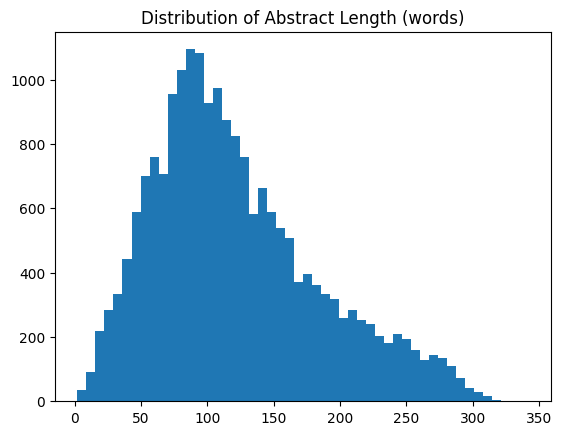

In [36]:

import matplotlib.pyplot as plt

plt.hist(df["length_words"], bins=50)
plt.title("Distribution of Abstract Length (words)")
plt.show()

In [37]:
# removing stop words: they could influence the analysis because they are present in almost each token
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
split_regex = r'\W+'
stop_words = set(ENGLISH_STOP_WORDS)

def simple_tokenize_no_stop(string):
    tokens = [s for s in re.split(split_regex, string.lower()) if s != '']
    return [t for t in tokens if t not in stop_words]

df["tokens"] = df["abstract"].apply(simple_tokenize_no_stop)


In [38]:
# example to see if it works
print(df)

              id                                           abstract  \
0      0704.0001    A fully differential calculation in perturba...   
1      0704.0002    We describe a new algorithm, the $(k,\ell)$-...   
2      0704.0003    The evolution of Earth-Moon system is descri...   
3      0704.0004    We show that a determinant of Stirling cycle...   
4      0704.0005    In this paper we show how to compute the $\L...   
...          ...                                                ...   
19995  0708.2144    I discuss certain applications of the Ricci ...   
19996  0708.2145    The Lattice Hadron Physics Collaboration (LH...   
19997  0708.2146    To solve the spinor-spinor Bethe-Salpeter eq...   
19998  0708.2147    Species coexistence is one of the central th...   
19999  0708.2148    The single- and two-channel Kondo lattice mo...   

       length_characters  length_words  \
0                    983           140   
1                    798           115   
2                    

In [10]:
total_tokens = df["tokens"].apply(len).sum()
print(f"There are {total_tokens} tokens in the dataset")

There are 1493306 tokens in the dataset


*Application of the algorithms*

---

At first the Jaccard similarity was tested on the subsets directly



In [39]:
df["tokens_set"] = df["tokens"].apply(set)

In [40]:
subset = df.head(2000).reset_index(drop=True)

In [41]:
# Jaccard similarity function
def Jaccard_similarity(set1, set2):
  return len(set1 & set2)/ len(set1 | set2)

In [42]:
pairs_jaccard = []
for i in range(len(subset)):
  for j in range(i+1, len(subset)):
    similarity_level = Jaccard_similarity(subset.loc[i, "tokens_set"], subset.loc[j, "tokens_set"])
    pairs_jaccard.append((subset.loc[i,'id'], subset.loc[j,'id'], similarity_level))

In [43]:
# Dataframe created
similar_pairs_df = pd.DataFrame(pairs_jaccard, columns = ['Id1', 'Id2', 'Jaccard_similarity'])
similar_pairs_df = similar_pairs_df.sort_values(by='Jaccard_similarity', ascending=False)
similar_pairs_df.head(10)

,Id1,Id2,Jaccard_similarity
856767,0704.0489,0704.0573,1.000000
49760,0704.0026,0704.0112,1.000000
1244404,0704.0772,0704.0783,0.844444
1257850,0704.0783,0704.0787,0.555556
1244408,0704.0772,0704.0787,0.479167
1939320,0704.1655,0704.1661,0.470588
413913,0704.0220,0704.0224,0.460000
776925,0704.0437,0704.0629,0.441176
1527094,0704.1029,0704.1030,0.408163
298833,0704.0156,0704.1080,0.400000


In [44]:
# example of the abstract with jaccard similarity = 0.8444
ids_to_print = ['0704.0772', '0704.0783']

for doc_id in ids_to_print:
    abstract_text = df.loc[df['id'] == doc_id, 'abstract'].values[0]
    tokens = df.loc[df['id'] == doc_id, 'tokens_set'].values[0]
    print(f"ID: {doc_id}")
    print("Abstract:")
    print(abstract_text)
    print("Tokens:")
    print(tokens)
    print("-"*50)

ID: 0704.0772
Abstract:
  We introduce a finite volume scheme for the two-dimensional incompressible
Navier-Stokes equations. We use a triangular mesh. The unknowns for the
velocity and pressure are both piecewise constant (colocated scheme). We use a
projection (fractional-step) method to deal with the incompressibility
constraint. We prove that the differential operators in the Navier-Stokes
equations and their discrete counterparts share similar properties. In
particular, we state an inf-sup (Babuska-Brezzi) condition. We infer from it
the stability of the scheme.

Tokens:
{'infer', 'scheme', 'method', 'prove', 'volume', 'finite', 'properties', 'deal', 'triangular', 'fractional', 'colocated', 'stability', 'introduce', 'operators', 'unknowns', 'incompressibility', 'share', 'particular', 'velocity', 'inf', 'pressure', 'counterparts', 'piecewise', 'equations', 'babuska', 'discrete', 'differential', 'constant', 'similar', 'mesh', 'use', 'dimensional', 'stokes', 'constraint', 'step', 'su

Implementation of approximation techniques -> MinHash and LSH



In [45]:
from datasketch import MinHash, MinHashLSH
num_permutation = 100
minhashes = []

for token in df["tokens_set"]:
  m = MinHash(num_perm=num_permutation)
  for t in token:
    m.update(t.encode('utf8'))
  minhashes.append(m)



In [46]:
# example
sim = minhashes[0].jaccard(minhashes[34])
print(f"Jaccard similarity between abstract 0 and abstract 34 is {sim:.2f}")

Jaccard similarity between abstract 0 and abstract 34 is 0.08


In [19]:
#check
print(df["tokens_set"][0])
print(df["tokens_set"][34])

{'subprocesses', 'space', 'massive', 'selection', 'energy', 'anti', 'leading', 'good', 'showing', 'order', 'quantum', 'accuracy', 'processes', 'distributions', 'shown', 'state', 'initial', 'presented', 'resummation', 'decay', 'tests', 'lhc', 'collider', 'contrasted', 'region', 'large', 'fully', 'antiquark', 'predictions', 'contributions', 'chromodynamics', 'enhanced', 'gluon', 'pairs', 'sensitivity', 'included', 'valid', 'events', 'demonstrated', 'tevatron', 'differential', 'phase', 'calculation', 'production', 'logarithmic', 'colliders', 'reliable', 'cdf', 'produced', 'orders', 'judicious', 'data', 'fermilab', 'specified', 'agreement', 'obtained', 'photon', 'detailed', 'diphoton', 'hadron', 'qcd', 'higgs', 'signal', 'quark', 'boson', 'radiation', 'perturbative'}
{'especially', 'shaped', 'method', 'illustrated', 'magnitude', 'based', 'proven', 'extrapolation', 'order', 'case', 'dipole', 'accuracy', 'propose', 'shape', 'approximation', 'technique', 'error', 'performance', '5', 'reaching

In [47]:
# comparison between Jaccard similarity and the approssimation with Minhash on a small subset
import random
random.seed(42)
num_pairs = 200
pairs = []

for n in range(num_pairs):
  i = random.randint(0, len(subset) - 1)
  j = random.randint(0, len(subset) - 1)
  if i!=j:
    pairs.append((i, j))

In [48]:
results_jaccard = []
for i, j in pairs:
  set1 = subset.loc[i, "tokens_set"]
  set2 = subset.loc[j, "tokens_set"]

  # Jaccard similarity
  true_jaccard = Jaccard_similarity(set1, set2)

  # Jaccard approssimation
  approximate_jaccard = minhashes[i].jaccard(minhashes[j])

  results_jaccard.append((true_jaccard, approximate_jaccard))

In [60]:
df_comparison_Jaccard = pd.DataFrame(results_jaccard, columns = ["true_jaccard", "approximate_jaccard"])
df_comparison_Jaccard.sample(10)

,true_jaccard,approximate_jaccard
176,0.010417,0.02
33,0.020000,0.04
121,0.040984,0.06
180,0.000000,0.00
102,0.019608,0.01
135,0.037037,0.05
88,0.010870,0.01
76,0.030303,0.04
65,0.000000,0.00
124,0.025157,0.02


In [50]:
# error between jaccard and minhash values calculated
df_comparison_Jaccard["error"] = abs(df_comparison_Jaccard ["true_jaccard"] - df_comparison_Jaccard ["approximate_jaccard"])
df_comparison_Jaccard["error"].describe()

,error
count,200.000000
mean,0.007908
std,0.009216
min,0.000000
25%,0.000583
50%,0.005505
75%,0.011263
max,0.047528


LSH+MinHash implementation


In [51]:
# comparing of different threshold
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for t in thresholds:
  lsh = MinHashLSH(threshold=t, num_perm = num_permutation)
  for i, m in enumerate(minhashes):
      lsh.insert(f"abstract{i}", m)
  similar_abstract_count = 0

  for i, m in enumerate(minhashes):
    result = lsh.query(m)
    result =  [r for r in result if r != f"abstract{i}"]
    similar_abstract_count += len(result)

  results.append((t, similar_abstract_count))


df_result_compared= pd.DataFrame(results, columns = ["threshold", "num_similar_abstract"])
print(df_result_compared)


   threshold  num_similar_abstract
0        0.3                498308
1        0.4                 16148
2        0.5                  1802
3        0.6                   576
4        0.7                   260


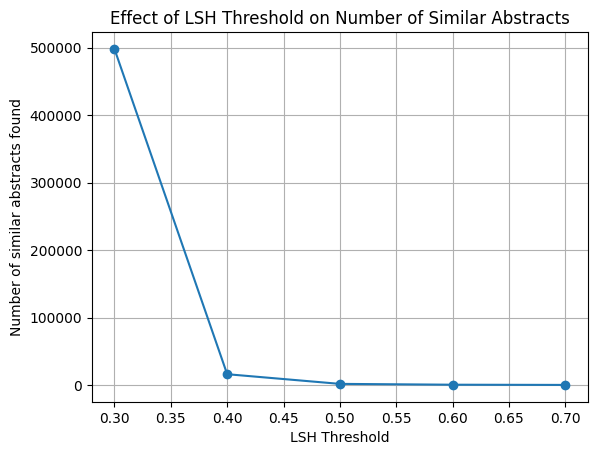

In [25]:
plt.plot(df_result_compared["threshold"], df_result_compared["num_similar_abstract"], marker='o')
plt.xlabel("LSH Threshold")
plt.ylabel("Number of similar abstracts found")
plt.title("Effect of LSH Threshold on Number of Similar Abstracts")
plt.grid(True)
plt.show()

In [52]:
# threshold = 0.5
lsh = MinHashLSH(threshold=0.5, num_perm = num_permutation)

for i, m in enumerate(minhashes):
    lsh.insert(f"abstract{i}", m)

In [53]:
#search for similar abstract
similar_abstract = {}

for i, m in enumerate(minhashes):
  result = lsh.query(m)
  result =  [r for r in result if r != f"abstract{i}"]
  similar_abstract[f"abstract{i}"] = result


for element, num in list(similar_abstract.items())[:10]:
  print(f"{element} ha abstract simili: {num}")

abstract0 ha abstract simili: []
abstract1 ha abstract simili: []
abstract2 ha abstract simili: []
abstract3 ha abstract simili: []
abstract4 ha abstract simili: []
abstract5 ha abstract simili: ['abstract7971']
abstract6 ha abstract simili: []
abstract7 ha abstract simili: []
abstract8 ha abstract simili: []
abstract9 ha abstract simili: []


In [54]:
df_similar_items = pd.DataFrame([
    {"Abstract": element, "num_similar": len(similars)}
    for element, similars in similar_abstract.items()
])

df_similar_items = df_similar_items[df_similar_items["num_similar"] > 0]
print(df_similar_items.sort_values(by= "num_similar", ascending= False))

            Abstract  num_similar
10933  abstract10933           19
5696    abstract5696           18
3766    abstract3766           18
6560    abstract6560           18
19509  abstract19509           18
...              ...          ...
19351  abstract19351            1
99        abstract99            1
111      abstract111            1
114      abstract114            1
133      abstract133            1

[1043 rows x 2 columns]


In [55]:
# table for the report
df_similar_items_sorted = df_similar_items.sort_values(by="num_similar", ascending=False).head(10)
print(df_similar_items_sorted)

            Abstract  num_similar
10933  abstract10933           19
5696    abstract5696           18
3766    abstract3766           18
6560    abstract6560           18
19509  abstract19509           18
3676    abstract3676           18
18655  abstract18655           18
13315  abstract13315           18
14376  abstract14376           18
9065    abstract9065           15


In [56]:
max_examples = 3
count = 0

for key, similars in similar_abstract.items():
    if similars:
        idx = int(key.replace("abstract", ""))
        print(f"\nAbstract {idx} (testo originale):")
        print(df.iloc[idx]['abstract'])

        for s in similars:
            sim_idx = int(s.replace("abstract", ""))
            print(f" - Simile a abstract {sim_idx}: {df.iloc[sim_idx]['abstract']}")

        count += 1
        if count >= max_examples:
            break


Abstract 5 (testo originale):
  We study the two-particle wave function of paired atoms in a Fermi gas with
tunable interaction strengths controlled by Feshbach resonance. The Cooper pair
wave function is examined for its bosonic characters, which is quantified by
the correction of Bose enhancement factor associated with the creation and
annihilation composite particle operators. An example is given for a
three-dimensional uniform gas. Two definitions of Cooper pair wave function are
examined. One of which is chosen to reflect the off-diagonal long range order
(ODLRO). Another one corresponds to a pair projection of a BCS state. On the
side with negative scattering length, we found that paired atoms described by
ODLRO are more bosonic than the pair projected definition. It is also found
that at $(k_F a)^{-1} \ge 1$, both definitions give similar results, where more
than 90% of the atoms occupy the corresponding molecular condensates.

 - Simile a abstract 7971:   Inequalities are deri

In [57]:
# scalability
import time
subset_dimension = [100, 1000, 2000]
time_jaccard = []
time_minhash = []

for s in subset_dimension:
  sub = df.head(s).reset_index(drop=True)
  start = time.time()
  for i in range(len(sub)):
    for j in range(i+1, len(sub)):
      Jaccard_similarity(sub.loc[i, "tokens_set"], sub.loc[j, "tokens_set"])
  end = time.time()
  time_jaccard.append(end - start)

In [58]:
num_permutation= 100
for s in subset_dimension:
  sub = df.head(s).reset_index(drop=True)
  start = time.time()
  minhash_sub = []
  for token in sub["tokens_set"]:
    m = MinHash(num_perm=num_permutation)
    for t in token:
      m.update(t.encode('utf8'))
    minhash_sub.append(m)

  end = time.time()
  time_minhash.append(end-start)

In [59]:
df.time = pd.DataFrame({
    "Subset size": subset_dimension,
    "Time Jaccard": time_jaccard,
    "time Minhash": time_minhash
    })

print(df.time)

   Subset size  Time Jaccard  time Minhash
0          100       0.10430      0.181770
1         1000      13.74866      2.339651
2         2000      55.01278      5.422715


/tmp/ipykernel_3813/1193462537.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.time = pd.DataFrame({
